# 02 — Prototype the Silver transforms

Stage 2 is designed but not implemented (`docs/SETUP.md` §0). The two
transforms Silver needs — natural-key dedupe and event-time bars — are cheap
to get wrong in ways that only show up much later, so get the semantics right
here in pandas first, then port them.

Each section ends with the PySpark it maps to. This notebook is where the
*decision* is made; the pipeline is where it gets executed at scale.

In [1]:
import devlab
from devlab import frames
from devlab.frames import NATURAL_KEY

target = devlab.resolve()
records = devlab.collect(target, limit=20_000, seconds=60.0, offset_reset="earliest")
raw = frames.trades_frame(records)
print(f"{len(raw):,} raw records")
NATURAL_KEY

20,000 raw records


['venue', 'venue_symbol', 'trade_id']

## 1. Dedupe on the natural key

`(venue, venue_symbol, trade_id)` is the identity of a trade. `trade_id` alone
is **not** unique — it is only unique within a venue, and both venues number
from 1.

Duplicates are expected, not a bug: REST gap repair re-fetches a range that
partly overlaps what the stream already delivered, and archive backfill will
re-emit history that is already in the log. Both are deliberate (see the
Coinbase connector's "best-effort repair" note). Silver absorbs the overlap.

In [10]:
duplicated = raw[raw.duplicated(subset=NATURAL_KEY, keep=False)]
print(f"{len(duplicated):,} rows share a natural key with another row")
duplicated.sort_values(NATURAL_KEY)[[*NATURAL_KEY, "source", "kafka_offset", "price"]].head(20)

806 rows share a natural key with another row


,venue,venue_symbol,trade_id,source,kafka_offset,price
36,coinbase,BTC-USD,1068484311,STREAM,102,64841.44
37,coinbase,BTC-USD,1068484311,REST_REPAIR,210,64841.44
38,coinbase,BTC-USD,1068484312,STREAM,101,64841.43
39,coinbase,BTC-USD,1068484312,REST_REPAIR,209,64841.43
54,coinbase,BTC-USD,1068484313,REST_REPAIR,208,64841.43
55,coinbase,BTC-USD,1068484313,STREAM,100,64841.43
56,coinbase,BTC-USD,1068484314,REST_REPAIR,207,64841.43
57,coinbase,BTC-USD,1068484314,STREAM,99,64841.43
66,coinbase,BTC-USD,1068484315,REST_REPAIR,206,64841.44
67,coinbase,BTC-USD,1068484315,STREAM,98,64841.44


In [3]:
silver = frames.dedupe(raw)
print(f"{len(raw):,} raw -> {len(silver):,} deduped ({len(raw) - len(silver):,} dropped)")
silver["source"].value_counts()

20,000 raw -> 19,597 deduped (403 dropped)


source
STREAM         19592
REST_REPAIR        5
Name: count, dtype: int64

Check the drop is real rather than an over-collapse: if `trade_id` were being
compared across venues, the count would fall by roughly half.

In [4]:
frames.frame(
    silver.groupby("venue", observed=True)
    .agg(trades=("trade_id", "count"), unique_ids=("trade_id", "nunique"))
    .reset_index()
    .to_dict("records")
)

,venue,trades,unique_ids
0,binance,7768,7768
1,coinbase,11829,11829


**PySpark equivalent**

```python
from pyspark.sql import functions as F, Window

window = Window.partitionBy(*NATURAL_KEY).orderBy("event_ts", "kafka_offset")
silver = (
    bronze
    .withColumn("_rank", F.row_number().over(window))
    .filter(F.col("_rank") == 1)
    .drop("_rank")
)
```

`dropDuplicates(NATURAL_KEY)` is shorter but picks an arbitrary survivor. The
window makes the tie-break explicit, which matters when a `STREAM` row and a
`REST_REPAIR` row disagree.

For streaming, this needs `withWatermark("event_ts", ...)` bounding how late a
repair may arrive — the repair latency is your watermark floor.

## 2. Event-time bars

Built on `event_ts` (exchange time), never `ingest_ts`. Using arrival time
would let a slow consumer reshape the data — replay the same log through a
loaded cluster and you would get different bars, which is exactly the
non-determinism a lakehouse is supposed to eliminate.

Dedupe first. Duplicated trades inflate both volume and VWAP.

In [5]:
bars = frames.bars(silver, freq="1min")
bars.tail(10)

,instrument_id,event_ts,open,high,low,close,volume,notional,trades,vwap
406,XRP-USD,2026-08-09 15:53:00+00:00,1.0429,1.0432,1.0428,1.0430,36093.5,37643.16892,25,1.042935
407,XRP-USD,2026-08-09 15:54:00+00:00,1.0430,1.0433,1.0429,1.0433,105368.2,109905.44477,33,1.043061
408,XRP-USD,2026-08-09 15:55:00+00:00,1.0434,1.0434,1.0430,1.0431,10566.7,11023.85216,28,1.043263
409,XRP-USD,2026-08-09 15:56:00+00:00,1.0431,1.0432,1.0431,1.0431,5147.3,5369.26492,18,1.043123
410,XRP-USD,2026-08-09 15:57:00+00:00,1.0432,1.0436,1.0432,1.0435,5487.6,5725.17072,25,1.043292
411,XRP-USD,2026-08-09 15:58:00+00:00,1.0436,1.0437,1.0433,1.0433,14709.4,15350.69986,27,1.043598
412,XRP-USD,2026-08-09 15:59:00+00:00,1.0433,1.0434,1.0432,1.0432,24374.8,25429.28538,30,1.043261
413,XRP-USD,2026-08-09 16:00:00+00:00,1.0432,1.0443,1.0432,1.0438,75613.5,78923.58729,103,1.043776
414,XRP-USD,2026-08-09 16:01:00+00:00,1.0439,1.0440,1.0435,1.0435,14008.4,14621.52711,33,1.043769
415,XRP-USD,2026-08-09 16:02:00+00:00,1.0435,1.0435,1.0427,1.0431,23605.9,24619.68714,33,1.042946


Sanity check: VWAP must sit within the bar's `low..high`. A weighted mean of
values drawn from that range, with non-negative weights, cannot escape it — so
a real violation means the volume weighting is wrong.

The tolerance is not slop. On a **flat bar** (every trade at one price)
`sum(p*s) / sum(s)` is `p` only up to float64 rounding, and lands roughly one
ulp outside `low..high`. Verified against live data: 6 of 97 bars tripped a
zero-tolerance check, all flat, all off by ~9e-16 — noise, not a defect.

It is also the argument for `decimal(38, 18)` rather than `double` in Spark:
the wire format keeps prices exact as strings, and Silver should not be the
place that quietly stops being exact.

In [7]:
tolerance = 1e-9 * bars["high"].abs()  # float64 noise on flat bars, not a breach
outside = bars[(bars["vwap"] < bars["low"] - tolerance) | (bars["vwap"] > bars["high"] + tolerance)]
print(f"{len(outside)} bars with VWAP outside low..high (expected 0)")
outside

0 bars with VWAP outside low..high (expected 0)


,instrument_id,event_ts,open,high,low,close,volume,notional,trades,vwap


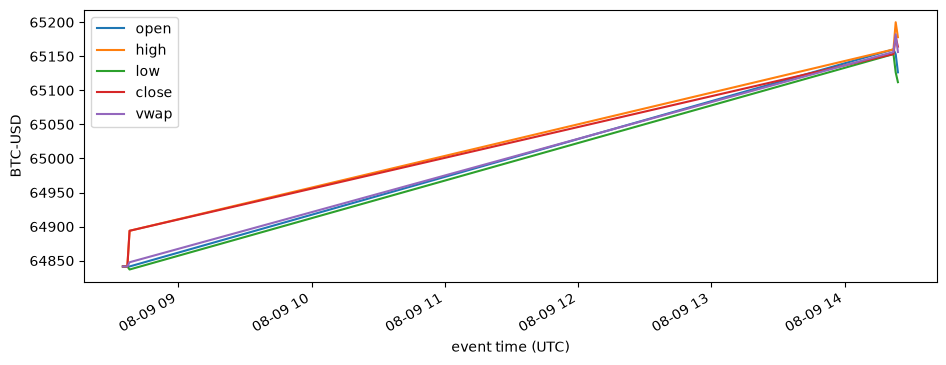

In [8]:
btc = bars[bars["instrument_id"] == "BTC-USD"]
if not btc.empty:
    axis = btc.plot(x="event_ts", y=["open", "high", "low", "close", "vwap"], figsize=(11, 4))
    axis.set_ylabel("BTC-USD")
    axis.set_xlabel("event time (UTC)")

The default groups by `instrument_id` alone — a **consolidated tape** across
venues. That is a real modelling decision, not a default to accept silently:
it treats a Binance trade and a Coinbase trade in the same instrument as the
same market. Pass `by=["venue", "instrument_id"]` for per-venue bars.

In [9]:
frames.bars(silver, freq="1min", by=["venue", "instrument_id"]).tail(8)

,venue,instrument_id,event_ts,open,high,low,close,volume,notional,trades,vwap
411,coinbase,SOL-USD,2026-08-09 15:55:00+00:00,77.16,77.26,77.14,77.24,2648.704648,204404.350278,234,77.171439
412,coinbase,SOL-USD,2026-08-09 15:56:00+00:00,77.25,77.29,77.21,77.24,2460.088716,190022.997395,192,77.242335
413,coinbase,SOL-USD,2026-08-09 15:57:00+00:00,77.24,77.40,77.24,77.39,4150.930925,321114.776850,240,77.359701
414,coinbase,SOL-USD,2026-08-09 15:58:00+00:00,77.38,77.40,77.31,77.31,1482.346023,114684.792718,110,77.367086
415,coinbase,SOL-USD,2026-08-09 15:59:00+00:00,77.32,77.36,77.30,77.36,466.610362,36078.393804,83,77.320173
416,coinbase,SOL-USD,2026-08-09 16:00:00+00:00,77.36,77.42,77.27,77.40,4454.053538,344527.032910,227,77.351345
417,coinbase,SOL-USD,2026-08-09 16:01:00+00:00,77.42,77.43,77.36,77.37,3872.347465,299634.001783,205,77.377871
418,coinbase,SOL-USD,2026-08-09 16:02:00+00:00,77.36,77.36,77.31,77.31,332.058567,25680.428554,47,77.337046


**PySpark equivalent**

```python
gold = (
    silver
    .groupBy(F.window("event_ts", "1 minute"), "instrument_id")
    .agg(
        F.first("price").alias("open"),
        F.max("price").alias("high"),
        F.min("price").alias("low"),
        F.last("price").alias("close"),
        F.sum("size").alias("volume"),
        F.sum("notional").alias("notional"),
        F.count("*").alias("trades"),
    )
    .withColumn("vwap", F.col("notional") / F.col("volume"))
)
```

Two differences from pandas that will bite:

- `F.first` / `F.last` are **not** ordered unless the input is. `pd.Grouper`
  preserves the sorted index; Spark does not. Order within the window, or use
  `min_by("price", "event_ts")` / `max_by`.
- `price` and `size` are strings on the wire. Cast to `decimal(38, 18)` in
  Spark rather than double — this notebook uses float64 for convenience, but
  Silver should not throw away the precision the wire format preserves.